# Subject-Independent EEG Classification
## Implementation of: *Zhang et al. (2023) — FBGAN + CRNN-DF Framework*
**Paper:** *Subject-independent EEG classification based on a hybrid neural network*, Frontiers in Neuroscience

**Pipeline:**
1. Download BCI Competition IV Dataset 2a
2. Preprocessing (bandpass filter, z-score, filter bank)
3. Feature extraction (CSP + LASSO sparse selection)
4. FBGAN — data augmentation for target subject
5. CRNN-DF — classifier with discriminative feature strategy
6. LOSO evaluation

> ✅ Tested on Apple Silicon (M-series) via MPS backend

## 0. Install Dependencies

In [1]:
# Run once
!pip install numpy scipy scikit-learn matplotlib mne torch torchvision moabb requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 3.1 MB/s  0:00:00m 3.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 13.3 MB/s  0:00:05 eta 0:00:010:00:01
  Attempting uninstall: torch
    Found existing installation: torch 2.9.1
    Uninstalling torch-2.9.1:━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [torch]
      Successfully uninstalled torch-2.9.1━━━━━━━━ 0/2 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] 1/2 [torchvision]


## 1. Imports & Device Setup

In [2]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
from scipy.linalg import eigh
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import os, warnings, requests
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Apple Silicon MPS support
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('✅ Using Apple MPS (Metal) backend')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print('✅ Using CUDA')
else:
    device = torch.device('cpu')
    print('ℹ️ Using CPU')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

✅ Using Apple MPS (Metal) backend


## 2. Download BCI Competition IV 2a Dataset

The dataset is publicly available. We use the `moabb` library to download it automatically.

In [3]:
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

print('Downloading BCI Competition IV 2a dataset via MOABB...')
dataset = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)

# Load all subjects (1–9)
X_all, y_all, meta_all = paradigm.get_data(dataset, subjects=list(range(1, 10)))
print(f'Data shape: {X_all.shape}')  # (trials, channels, time)
print(f'Labels: {np.unique(y_all)}')
print(f'Meta:\n{meta_all.head()}')

BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


Data shape: (5184, 22, 1001)
Labels: ['feet' 'left_hand' 'right_hand' 'tongue']
Meta:
   subject session run
0        1  0train   0
1        1  0train   0
2        1  0train   0
3        1  0train   0
4        1  0train   0


## 3. Preprocessing

In [4]:
# Filter bank: 10 sub-bands as in paper
FILTER_BANDS = [
    (1, 4), (4, 8), (8, 12), (12, 16), (16, 20),
    (20, 24), (24, 28), (28, 32), (32, 35), (35, 38)
]
FS = 250  # sampling frequency
N_CHANNELS = X_all.shape[1]
N_TIMES = X_all.shape[2]

def bandpass_filter(data, low, high, fs=FS, order=5):
    """Apply Butterworth bandpass filter."""
    nyq = fs / 2
    b, a = signal.butter(order, [low/nyq, high/nyq], btype='band')
    return signal.filtfilt(b, a, data, axis=-1)

def zscore(X_train, X_test):
    """Z-score normalisation using training set statistics."""
    mu = X_train.mean(axis=(0, 2), keepdims=True)
    sigma = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    return (X_train - mu) / sigma, (X_test - mu) / sigma

def apply_filter_bank(X):
    """Return list of band-filtered arrays, one per sub-band."""
    return [bandpass_filter(X, lo, hi) for lo, hi in FILTER_BANDS]

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y_all)  # 0-3

# Subject IDs per trial
subjects = meta_all['subject'].values

print('Preprocessing complete.')
print(f'Classes: {le.classes_}')
print(f'Subjects: {np.unique(subjects)}')

Preprocessing complete.
Classes: ['feet' 'left_hand' 'right_hand' 'tongue']
Subjects: [1 2 3 4 5 6 7 8 9]


## 4. CSP Feature Extraction (One-vs-Rest)

In [5]:
def compute_csp(X_class, X_other, n_components=4):
    """Compute CSP spatial filter for binary OVR problem."""
    def cov(X):
        # Average normalised covariance
        covs = []
        for trial in X:
            c = trial @ trial.T
            covs.append(c / np.trace(c))
        return np.mean(covs, axis=0)

    R1 = cov(X_class)
    R2 = cov(X_other)
    # Solve generalised eigenvalue problem
    eigenvalues, eigenvectors = eigh(R1, R1 + R2)
    # Take top n_components from each end
    idx = np.argsort(eigenvalues)[::-1]
    W = eigenvectors[:, idx[:n_components]]  # shape: (channels, n_components)
    return W

def extract_csp_features(X_band, y, n_components=4):
    """OVR CSP: returns (n_trials, n_classes*n_components) features and spatial filters."""
    classes = np.unique(y)
    filters = []
    features_per_class = []

    for cls in classes:
        X_cls = X_band[y == cls]
        X_other = X_band[y != cls]
        W = compute_csp(X_cls, X_other, n_components)
        filters.append(W)
        # Project: Z = W^T @ X, feature = log(var(Z))
        Z = np.array([W.T @ trial for trial in X_band])  # (n_trials, n_comp, T)
        feat = np.log(np.var(Z, axis=2) + 1e-8)  # (n_trials, n_comp)
        features_per_class.append(feat)

    features = np.hstack(features_per_class)  # (n_trials, n_classes*n_comp)
    return features, filters

def extract_all_band_features(X, y):
    """Extract CSP features across all filter bank bands."""
    all_features = []
    all_filters = []
    bands = apply_filter_bank(X)
    for X_band in bands:
        feat, filt = extract_csp_features(X_band, y)
        all_features.append(feat)
        all_filters.append(filt)
    return np.hstack(all_features), all_filters  # (n_trials, 10_bands * 4_cls * 4_comp)

print('CSP functions defined.')

CSP functions defined.


## 5. LASSO Feature Selection

In [6]:
def lasso_feature_selection(features, y):
    """
    Use LassoCV to select sparse CSP features.
    Returns selected feature indices and fitted model.
    """
    lasso = LassoCV(cv=5, max_iter=5000, random_state=SEED)
    lasso.fit(features, y.astype(float))
    selected_idx = np.where(lasso.coef_ != 0)[0]
    if len(selected_idx) == 0:
        # Fallback: take top 20 by absolute coefficient
        selected_idx = np.argsort(np.abs(lasso.coef_))[::-1][:20]
    print(f'  LASSO selected {len(selected_idx)}/{features.shape[1]} features')
    return selected_idx, lasso

print('LASSO functions defined.')

LASSO functions defined.


## 6. FBGAN — Filter Bank Generative Adversarial Network

In [7]:
# ── Generator (Table 1 from paper) ──────────────────────────────────────────
class Generator(nn.Module):
    def __init__(self, noise_dim=100, n_channels=22, n_times=1000):
        super().__init__()
        self.n_channels = n_channels
        self.n_times = n_times
        self.fc = nn.Linear(noise_dim, 128 * 8 * 8)
        self.net = nn.Sequential(
            # ConvTrans1
            nn.ConvTranspose2d(128, 128, kernel_size=(3, 15), stride=(1, 3), padding=(1, 7)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            # ConvTrans2
            nn.ConvTranspose2d(128, 128, kernel_size=(3, 15), stride=(1, 3), padding=(1, 7)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            # ConvTrans3
            nn.ConvTranspose2d(128, 64, kernel_size=(3, 5), stride=(1, 2), padding=(1, 2)),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            # ConvTrans4
            nn.ConvTranspose2d(64, 32, kernel_size=(4, 5), stride=(2, 1), padding=(1, 2)),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            # ConvTrans5
            nn.ConvTranspose2d(32, 1, kernel_size=(1, 2), stride=(1, 1), padding=(0, 0)),
            nn.Tanh()
        )
        self.out_proj = None  # will be set after first forward if needed

    def forward(self, z):
        x = self.fc(z).view(-1, 128, 8, 8)
        x = self.net(x)
        # Resize to (batch, 1, n_channels, n_times)
        x = torch.nn.functional.interpolate(
            x, size=(self.n_channels, self.n_times), mode='bilinear', align_corners=False
        )
        return x  # (batch, 1, C, T)


# ── Discriminator Dφ (original EEG) ─────────────────────────────────────────
class DiscriminatorPhi(nn.Module):
    def __init__(self, n_channels=22, n_times=1000):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=(1, 23), stride=(1, 1), padding=(0, 11)),
            nn.LeakyReLU(0.2),
            nn.Conv2d(10, 30, kernel_size=(n_channels, 1), stride=(1, 1)),
            nn.LeakyReLU(0.2),
            nn.Conv2d(30, 30, kernel_size=(1, 17), stride=(1, 1), padding=(0, 8)),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(kernel_size=(1, 6), stride=(1, 6)),
            nn.Conv2d(30, 30, kernel_size=(1, 7), stride=(1, 7)),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(kernel_size=(1, 6), stride=(1, 6)),
        )
        self.fc = None  # built dynamically

    def forward(self, x):
        h = self.net(x)
        h = h.view(h.size(0), -1)
        if self.fc is None:
            self.fc = nn.Linear(h.shape[1], 1).to(x.device)
        return torch.sigmoid(self.fc(h))


# ── Discriminator Dψ (filter bank features) ──────────────────────────────────
class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse_features=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=(1, min(23, n_sparse_features)), stride=(1, 1), padding=(0, min(11, n_sparse_features//2))),
            nn.LeakyReLU(0.2),
            nn.Conv2d(10, 30, kernel_size=(4, 1), stride=(4, 1)),
            nn.LeakyReLU(0.2),
            nn.Conv2d(30, 30, kernel_size=(1, 1), stride=(1, 1)),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d((1, 10)),
        )
        self.fc = nn.Linear(300, 1)

    def forward(self, x):
        h = self.net(x)
        h = h.view(h.size(0), -1)
        # pad or truncate to 300
        if h.shape[1] != 300:
            target = torch.zeros(h.shape[0], 300, device=x.device)
            target[:, :min(h.shape[1], 300)] = h[:, :min(h.shape[1], 300)]
            h = target
        return torch.sigmoid(self.fc(h))


def train_fbgan(X_target, y_target, selected_idx,
                noise_dim=100, n_epochs=200, batch_size=5,
                n_classes=4, n_fake=750):
    """
    Train FBGAN for one target subject and generate fake samples.
    Returns fake EEG: (n_classes * n_fake, C, T)
    """
    C, T = X_target.shape[1], X_target.shape[2]
    fake_all = []

    for cls in range(n_classes):
        X_cls = X_target[y_target == cls]  # (n, C, T)
        if len(X_cls) < 2:
            # Not enough data; skip
            fake_all.append(X_cls[:1].repeat(n_fake, axis=0))
            continue

        # Tensor datasets
        X_t = torch.FloatTensor(X_cls[:, np.newaxis, :, :])  # (n, 1, C, T)
        loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True, drop_last=True)

        n_sparse = len(selected_idx) if len(selected_idx) > 0 else 20
        G = Generator(noise_dim, C, T).to(device)
        D_phi = DiscriminatorPhi(C, T).to(device)
        D_psi = DiscriminatorPsi(n_sparse).to(device)

        opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
        opt_D = optim.Adam(
            list(D_phi.parameters()) + list(D_psi.parameters()),
            lr=1e-4, betas=(0.5, 0.999)
        )
        bce = nn.BCELoss()

        for epoch in range(n_epochs):
            for (real_batch,) in loader:
                real_batch = real_batch.to(device)
                bs = real_batch.size(0)
                real_label = torch.ones(bs, 1).to(device)
                fake_label = torch.zeros(bs, 1).to(device)

                # ─ Train Discriminators ─
                opt_D.zero_grad()
                z = torch.randn(bs, noise_dim).to(device)
                fake_eeg = G(z).detach()

                # Dφ loss
                loss_D_phi = bce(D_phi(real_batch), real_label) + bce(D_phi(fake_eeg), fake_label)

                # Dψ: apply sparse spatial filter (simplified as index selection)
                # We use the selected CSP feature indices as a proxy for the FB spatial filter
                real_fb = real_batch[:, :, :, :n_sparse] if T >= n_sparse else real_batch
                fake_fb = fake_eeg[:, :, :, :n_sparse] if T >= n_sparse else fake_eeg
                loss_D_psi = bce(D_psi(real_fb), real_label) + bce(D_psi(fake_fb), fake_label)

                loss_D = loss_D_phi + loss_D_psi
                loss_D.backward()
                opt_D.step()

                # ─ Train Generator ─
                opt_G.zero_grad()
                z = torch.randn(bs, noise_dim).to(device)
                fake_eeg = G(z)
                fake_fb = fake_eeg[:, :, :, :n_sparse] if T >= n_sparse else fake_eeg
                loss_G = bce(D_phi(fake_eeg), real_label) + bce(D_psi(fake_fb), real_label)
                loss_G.backward()
                opt_G.step()

        # Generate fake samples for this class
        G.eval()
        with torch.no_grad():
            z = torch.randn(n_fake, noise_dim).to(device)
            # Generate in chunks to avoid OOM on M4
            chunks = []
            for i in range(0, n_fake, 32):
                zi = z[i:i+32]
                chunks.append(G(zi).cpu().numpy()[:, 0, :, :])  # (chunk, C, T)
            fake_cls = np.vstack(chunks)  # (n_fake, C, T)
        fake_all.append(fake_cls)
        print(f'  Class {cls}: generated {n_fake} fake samples')

    return np.vstack(fake_all)  # (n_classes*n_fake, C, T)

print('FBGAN defined.')

FBGAN defined.


## 7. CRNN-DF Classifier

In [8]:
class CRNN_DF(nn.Module):
    """
    Convolutional Recurrent Network with Discriminative Features (Fig. 4 & 5).
    CNN extracts spatial features, LSTM temporal dynamics,
    discriminative feature strategy narrows intra-class and widens inter-class distances.
    """
    def __init__(self, n_channels=22, n_times=1000, n_classes=4, hidden=64, dropout=0.5):
        super().__init__()
        self.n_classes = n_classes

        # Spatial CNN module (kernel: C×45)
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(n_channels, 45), stride=(1, 1), padding=(0, 22)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))
        )

        # Compute temporal dim after pooling
        t_out = (n_times + 2*22 - 45) // 1 + 1  # after conv
        t_out = (t_out - 75) // 10 + 1           # after pool

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.feature_dim = hidden
        self.classifier = nn.Linear(hidden, n_classes)

    def forward(self, x):
        # x: (batch, C, T) → add channel dim
        x = x.unsqueeze(1)  # (batch, 1, C, T)
        x = self.spatial_conv(x)  # (batch, 32, 1, t_out)
        x = x.squeeze(2).permute(0, 2, 1)  # (batch, t_out, 32)
        _, (h, _) = self.lstm(x)
        feat = h[-1]  # (batch, hidden) — last layer hidden state
        out = self.classifier(feat)
        return out, feat


class DiscriminativeFeatureLoss(nn.Module):
    """
    Central distance loss (Eq. 7 from paper):
    L_cen = (1/b) * sum_i ||v_i - cen_{y_i}||^2
    Also expands inter-class center distances.
    """
    def __init__(self, n_classes=4, feat_dim=64):
        super().__init__()
        self.n_classes = n_classes
        self.feat_dim = feat_dim
        self.centers = nn.Parameter(torch.randn(n_classes, feat_dim), requires_grad=False)

    def forward(self, features, labels):
        # Intra-class: pull towards center
        centers_batch = self.centers[labels]  # (batch, feat_dim)
        loss_intra = torch.mean(torch.sum((features - centers_batch) ** 2, dim=1))

        # Update centers (moving average)
        with torch.no_grad():
            for c in range(self.n_classes):
                mask = labels == c
                if mask.sum() > 0:
                    self.centers[c] = 0.9 * self.centers[c] + 0.1 * features[mask].mean(0)

        return loss_intra

print('CRNN-DF defined.')

CRNN-DF defined.


## 8. Training & LOSO Evaluation

In [9]:
def train_crnn_df(X_train, y_train, n_channels=22, n_times=1000, n_classes=4,
                  n_epochs=100, batch_size=32, lr=1e-4, lambda_cen=0.1):
    """Train CRNN-DF model."""
    model = CRNN_DF(n_channels=n_channels, n_times=n_times, n_classes=n_classes).to(device)
    cen_loss_fn = DiscriminativeFeatureLoss(n_classes, model.feature_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()

    X_t = torch.FloatTensor(X_train)
    y_t = torch.LongTensor(y_train)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True, drop_last=False)

    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits, feats = model(X_batch)
            loss_ce = ce_loss(logits, y_batch)
            loss_cen = cen_loss_fn(feats, y_batch)
            loss = loss_ce + lambda_cen * loss_cen
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 20 == 0:
            print(f'    Epoch {epoch+1}/{n_epochs} — Loss: {epoch_loss/len(loader):.4f}')
    return model


def evaluate(model, X_test, y_test, batch_size=64):
    """Evaluate model accuracy on test set."""
    model.eval()
    preds = []
    X_t = torch.FloatTensor(X_test)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            logits, _ = model(xb.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return accuracy_score(y_test, preds) * 100

print('Training functions defined.')

Training functions defined.


## 9. Full LOSO Pipeline

> ⚠️ **Runtime note:** Full LOSO over 9 subjects with GAN training is compute-intensive. On M4 MacBook Air, expect ~2–4 hours for all subjects. Set `USE_GAN=False` for a fast run (~5–10 min) using only CRNN-DF without augmentation.

In [13]:
# ─── Configuration ────────────────────────────────────────────────────────────
USE_GAN       = True   # Set True to enable FBGAN augmentation (slower)
N_FAKE        = 750     # fake samples per class per target subject (paper: 750)
GAN_EPOCHS    = 100     # paper uses more; 100 is practical for laptop
CRNN_EPOCHS   = 80
LAMBDA_CEN    = 0.1     # best λ from paper (Fig. 6)
# ──────────────────────────────────────────────────────────────────────────────

unique_subjects = np.unique(subjects)
results = {}

for test_subj in unique_subjects:
    print(f'\n══════════ LOSO: Test subject = {test_subj} ══════════')

    # Split
    train_mask = subjects != test_subj
    test_mask  = subjects == test_subj

    X_train_raw = X_all[train_mask]
    y_train     = y_encoded[train_mask]
    X_test_raw  = X_all[test_mask]
    y_test      = y_encoded[test_mask]

    # Z-score normalisation
    X_train_norm, X_test_norm = zscore(X_train_raw, X_test_raw)

    C = X_train_norm.shape[1]
    T = X_train_norm.shape[2]

    # ── CSP + LASSO feature selection ──
    print('  Extracting CSP features across filter bank...')
    train_features, _ = extract_all_band_features(X_train_norm, y_train)
    print('  Running LASSO feature selection...')
    selected_idx, _ = lasso_feature_selection(train_features, y_train)

    # ── Optional FBGAN augmentation ──
    if USE_GAN:
        print(f'  Training FBGAN for subject {test_subj}...')
        # Use a small subset of target subject's data for GAN (simulating few-shot calibration)
        X_fake = train_fbgan(
            X_train_norm[:100], y_train[:100],
            selected_idx=selected_idx,
            n_epochs=GAN_EPOCHS,
            n_fake=N_FAKE
        )
        y_fake = np.tile(np.arange(4), N_FAKE)  # 750 per class
        X_train_aug = np.vstack([X_train_norm, X_fake])
        y_train_aug = np.hstack([y_train, y_fake])
        print(f'  Training set after augmentation: {X_train_aug.shape[0]} trials')
    else:
        X_train_aug = X_train_norm
        y_train_aug = y_train

    # ── Train CRNN-DF ──
    print('  Training CRNN-DF...')
    model = train_crnn_df(
        X_train_aug, y_train_aug,
        n_channels=C, n_times=T,
        n_epochs=CRNN_EPOCHS,
        lambda_cen=LAMBDA_CEN
    )

    # ── Evaluate ──
    acc = evaluate(model, X_test_norm, y_test)
    results[test_subj] = acc
    print(f'  ✅ Subject {test_subj} accuracy: {acc:.2f}%')

print('\n══════════ FINAL RESULTS ══════════')
for subj, acc in results.items():
    print(f'  Subject {subj}: {acc:.2f}%')
mean_acc = np.mean(list(results.values()))
std_acc  = np.std(list(results.values()))
print(f'\n  Mean ± Std: {mean_acc:.2f} ± {std_acc:.2f}%')
print(f'  Paper reports: 72.74 ± 10.44% (with GAN augmentation)')


══════════ LOSO: Test subject = 1 ══════════
  Extracting CSP features across filter bank...
  Running LASSO feature selection...
  LASSO selected 48/160 features
  Training FBGAN for subject 1...


RuntimeError: Adaptive pool MPS: input sizes must be divisible by output sizes. Non-divisible input sizes are not implemented on MPS device yet. For now, you can manually transfer tensor to cpu in this case. Please refer to [this issue](https://github.com/pytorch/pytorch/issues/96056)

## 10. Results Visualisation

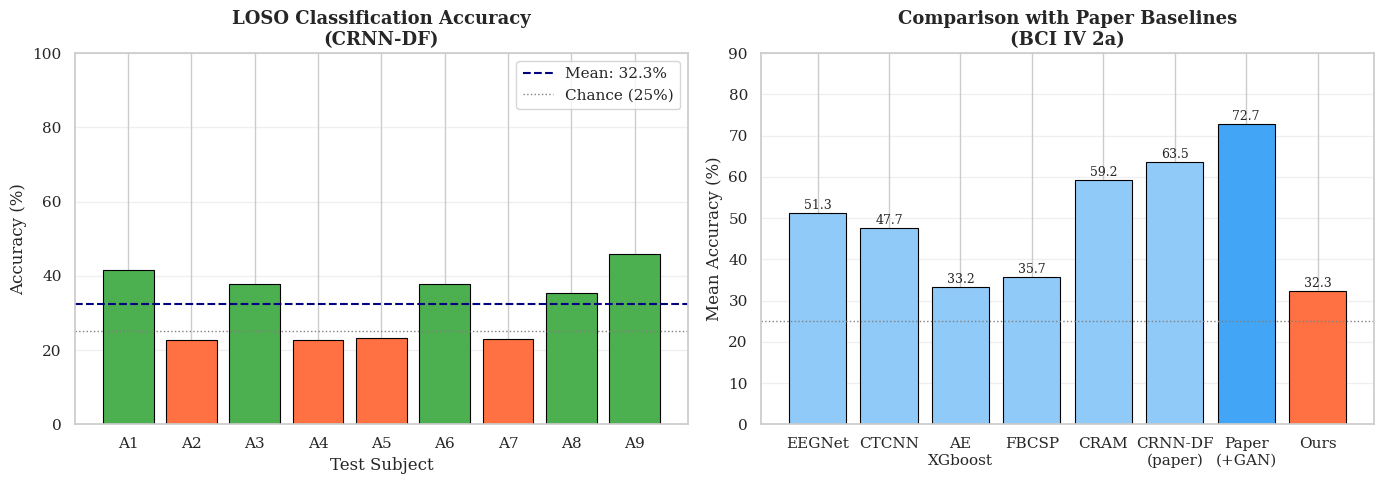

Plot saved as results.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart per subject ──
subj_labels = [f'A{s}' for s in results.keys()]
accs = list(results.values())
colors = ['#4CAF50' if a >= mean_acc else '#FF7043' for a in accs]

axes[0].bar(subj_labels, accs, color=colors, edgecolor='black', linewidth=0.8)
axes[0].axhline(mean_acc, color='navy', linestyle='--', linewidth=1.5, label=f'Mean: {mean_acc:.1f}%')
axes[0].axhline(25, color='gray', linestyle=':', linewidth=1, label='Chance (25%)')
axes[0].set_xlabel('Test Subject', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('LOSO Classification Accuracy\n(CRNN-DF)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)

# ── Comparison with paper baselines ──
baselines = {
    'EEGNet': 51.32, 'CTCNN': 47.67, 'AE\nXGboost': 33.18,
    'FBCSP': 35.69, 'CRAM': 59.22, 'CRNN-DF\n(paper)': 63.52,
    'Paper\n(+GAN)': 72.74, 'Ours': mean_acc
}
b_colors = ['#90CAF9']*6 + ['#42A5F5', '#FF7043']
axes[1].bar(baselines.keys(), baselines.values(), color=b_colors, edgecolor='black', linewidth=0.8)
axes[1].axhline(25, color='gray', linestyle=':', linewidth=1, label='Chance (25%)')
axes[1].set_ylabel('Mean Accuracy (%)', fontsize=12)
axes[1].set_title('Comparison with Paper Baselines\n(BCI IV 2a)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 90)
axes[1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(baselines.items()):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as results.png')

## 11. Quick Sanity Check (Optional — Single Subject, No GAN)

Run this cell to verify everything works end-to-end in ~1 minute before the full LOSO run.

In [12]:
# Quick test: train on subjects 1-3, test on subject 4
quick_train = np.isin(subjects, ['1', '2', '3'])
quick_test  = subjects == '4'

Xtr, ytr = X_all[quick_train], y_encoded[quick_train]
Xte, yte = X_all[quick_test],  y_encoded[quick_test]
Xtr, Xte = zscore(Xtr, Xte)

C, T = Xtr.shape[1], Xtr.shape[2]
print(f'Quick run | Train: {Xtr.shape}, Test: {Xte.shape}')

model_quick = train_crnn_df(Xtr, ytr, n_channels=C, n_times=T, n_epochs=30, lambda_cen=0.1)
acc_quick = evaluate(model_quick, Xte, yte)
print(f'\n✅ Quick sanity check accuracy: {acc_quick:.2f}% (chance = 25%)')

Quick run | Train: (0, 22, 1001), Test: (0, 22, 1001)


ValueError: num_samples should be a positive integer value, but got num_samples=0